In [1]:
PRJ_PATH = "/home/work/mlp/hslim/LASEF2"

TRANSLATED = False
ROLLOUT = True
ROLLOUT_COUNT = 10

MODEL = "Qwen2.5-7B-Instruct"
DATASET = "mgsm-all-low-resource-translated" # Example
# DATASET = "translated_skeleton" # Example
# DATASET = "single_rollout" # Example
DATA_DIR = f"{PRJ_PATH}/data/results/SkelLang/{DATASET}"
FASTTEXT_MODEL_PATH = f"{PRJ_PATH}/lid.176.bin"

SKELETON_LANGUAGES = ["zh", "es", "ru", "ko", "th"]

COT_LANGUAGES = ["ta", "kn", "my", "km", "am", "yo", "si", "gu", "ne", "uz", "ky", "ceb", "eu", "gn", "hy", "jv", "ka", "kk", "ku", "lo", "mg", "ml", "mn", "mr", "mt", "or", "pa", "ps", "qu", "sd", "so", "su", "tg", "ug"]

LANGUAGE_NAMES = {
        "ta": "Tamil", "kn": "Kannada", "my": "Burmese",
        "km": "Khmer", "am": "Amharic", "yo": "Yoruba",
        "si": "Sinhala", "gu": "Gujarati", "ne": "Nepali",
        "uz": "Uzbek", "ky": "Kyrgyz",
        "ceb": "Cebuano", "eu": "Basque", "gn": "Guarani",
        "hy": "Armenian", "jv": "Javanese", "ka": "Georgian",
        "kk": "Kazakh", "ku": "Kurdish", "lo": "Lao",
        "mg": "Malagasy", "ml": "Malayalam", "mn": "Mongolian",
        "mr": "Marathi", "mt": "Maltese", "or": "Odia",
        "pa": "Punjabi", "ps": "Pashto", "qu": "Quechua",
        "sd": "Sindhi", "so": "Somali", "su": "Sundanese",
        "tg": "Tajik", "ug": "Uyghur",
        "en": "English", "zh": "Chinese", "es": "Spanish",
        "ko": "Korean", "th": "Thai", "sw": "Swahili", "te": "Telugu",
    }
print(f"Model: {MODEL}")
print(f"Skeleton Languages: {SKELETON_LANGUAGES}")
print(f"CoT Languages: {COT_LANGUAGES}")

Model: Qwen2.5-7B-Instruct
Skeleton Languages: ['zh', 'es', 'ru', 'ko', 'th']
CoT Languages: ['ta', 'kn', 'my', 'km', 'am', 'yo', 'si', 'gu', 'ne', 'uz', 'ky', 'ceb', 'eu', 'gn', 'hy', 'jv', 'ka', 'kk', 'ku', 'lo', 'mg', 'ml', 'mn', 'mr', 'mt', 'or', 'pa', 'ps', 'qu', 'sd', 'so', 'su', 'tg', 'ug']


In [2]:
# ========================================
# Imports & FastText 로드
# ========================================
import fasttext
import json
import os
from collections import defaultdict
from multiprocessing import Pool, cpu_count
from tqdm import tqdm
from math_verify import parse, verify
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fasttext.FastText.eprint = lambda x: None
lang_model = fasttext.load_model(FASTTEXT_MODEL_PATH)
print("FastText model loaded successfully")

FastText model loaded successfully


In [3]:
# ========================================
# Helper Functions
# ========================================

from scipy.stats import wilcoxon

def calculate_wilcoxon_pvalue(scores_a, scores_b):
    diffs = [b - a for a, b in zip(scores_a, scores_b)]
    if all(d == 0 for d in diffs):
        return 1.0
    try:
        res = wilcoxon(scores_a, scores_b, zero_method='wilcox')
        return res.pvalue
    except ValueError:
        return 1.0

def detect_language(text):
    global lang_model
    if text is None or not isinstance(text, str):
        return "unk"
    text = text.replace("\n", " ").strip()
    if len(text) < 2:
        return "unk"
    try:
        labels, probs = lang_model.predict(text, k=1)
        if not probs or len(probs) == 0:
            return "unk"
        return labels[0].replace("__label__", "")
    except:
        return "unk"

def load_jsonl(filepath):
    import os, json
    data = []
    if not os.path.exists(filepath):
        print(f"⚠️ File not found: {filepath}")
        return None
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except:
                pass
    return data

def add_detected_languages(data, detect_skeleton=False):
    from tqdm import tqdm
    for item in tqdm(data, desc="Detecting languages", leave=False):
        responses = item.get('responses', [])[:ROLLOUT_COUNT]
        # responses = item.get('responses', [])[:ROLLOUT_COUNT]
        item['detected_response_languages'] = [detect_language(r if isinstance(r, str) else "") for r in responses]
        
        item['detected_response_language'] = item['detected_response_languages'][0] if item['detected_response_languages'] else "unk"
        
        if detect_skeleton:
            skeleton = item.get('skeleton', [])
            skel_text = skeleton[0] if isinstance(skeleton, list) and len(skeleton) > 0 else (skeleton if isinstance(skeleton, str) else "")
            item['detected_skeleton_language'] = detect_language(skel_text)
    return data

def group_by_language(data):
    from collections import defaultdict
    grouped = defaultdict(list)
    for item in data:
        lang = item.get('question_language', 'unknown')
        grouped[lang].append(item)
    return grouped

def evaluate_all_metrics(args):
    example_a, example_b, cot_lang = args
    responses_a = example_a.get('responses', [])[:ROLLOUT_COUNT]
    responses_b = example_b.get('responses', [])[:ROLLOUT_COUNT]
    langs_a = example_a.get('detected_response_languages', [])[:ROLLOUT_COUNT]
    langs_b = example_b.get('detected_response_languages', [])[:ROLLOUT_COUNT]
    
    try:
        from math_verify import parse, verify
        gold = parse(str(example_a['answer']))
        
        def get_metrics(responses, langs):
            if not responses: return 0.0, 0.0, 0.0
            
            scores_strict = []
            scores_pure = []
            compliances = []
            
            for r, l in zip(responses, langs):
                is_comp = (l == cot_lang)
                compliances.append(1.0 if is_comp else 0.0)
                
                try:
                    pred = parse(str(r))
                    is_correct = int(verify(gold, pred))
                except:
                    is_correct = 0
                    
                if is_comp:
                    scores_strict.append(is_correct)
                    scores_pure.append(is_correct)
                else:
                    scores_strict.append(0) # Option A: mismatch = 0
                    
            avg_strict = sum(scores_strict) / len(scores_strict)
            avg_pure = sum(scores_pure) / len(scores_pure) if scores_pure else float('nan')
            avg_comp = sum(compliances) / len(compliances)
            
            return avg_strict, avg_pure, avg_comp

        strict_a, pure_a, comp_a = get_metrics(responses_a, langs_a)
        strict_b, pure_b, comp_b = get_metrics(responses_b, langs_b)
        
        return strict_a, strict_b, pure_a, pure_b, comp_a, comp_b, 0
    except:
        return 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1

def get_baseline_path(tr, ro, roc):
    import os
    if tr:
        path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-en-Google-transQ{'_rollout'+str(roc) if ro else ''}.jsonl")
    else:
        # path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-en{'_rollout'+str(roc) if ro else ''}.jsonl")
        path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-en{'_rollout'+str(roc) if ro else ''}_exist.jsonl")
    return path

def get_skellang_path(skel_lang, tr, ro, roc):
    import os
    if tr:
        path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-{skel_lang}-Google-transQ{'_rollout'+str(roc) if ro else ''}.jsonl")
    else:
        # path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-{skel_lang}{'_rollout'+str(roc) if ro else ''}_translated_solved.jsonl")
        path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-{skel_lang}{'_rollout'+str(roc) if ro else ''}_exist.jsonl")
        # path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-{skel_lang}{'_rollout'+str(roc) if ro else ''}_temp03.jsonl")
    return path

print("Helper functions updated to 5-rollout multi-metrics.")

Helper functions updated to 5-rollout multi-metrics.


In [4]:
# ========================================
# Baseline 데이터 로드
# ========================================
print("📂 Loading baseline data (English skeleton)...")
baseline_path = get_baseline_path(TRANSLATED, ROLLOUT, ROLLOUT_COUNT)
baseline_data = load_jsonl(baseline_path)

if baseline_data:
    print(f"   Loaded {len(baseline_data)} examples")
    baseline_data = add_detected_languages(baseline_data, detect_skeleton=False)
    baseline_grouped = group_by_language(baseline_data)
    print(f"   Languages: {list(baseline_grouped.keys())}")
else:
    print("❌ Baseline file not found!")

📂 Loading baseline data (English skeleton)...
   Loaded 8500 examples


   Languages: ['ta', 'kn', 'my', 'km', 'am', 'yo', 'si', 'gu', 'ne', 'uz', 'ky', 'ceb', 'eu', 'gn', 'hy', 'jv', 'ka', 'kk', 'ku', 'lo', 'mg', 'ml', 'mn', 'mr', 'mt', 'or', 'pa', 'ps', 'qu', 'sd', 'so', 'su', 'tg', 'ug']


In [5]:
# ========================================
# 모든 Skeleton 언어에 대해 비교 수행
# ========================================

delta_matrix = defaultdict(dict)
accuracy_baseline = defaultdict(dict)
accuracy_target = defaultdict(dict)
sample_counts = defaultdict(dict)

for skel_lang in SKELETON_LANGUAGES:
    print(f"\n{'─'*60}")
    print(f"📊 Skeleton Language: {skel_lang.upper()} ({LANGUAGE_NAMES.get(skel_lang, skel_lang)})")
    print(f"{'─'*60}")
    
    target_path = get_skellang_path(skel_lang, TRANSLATED, ROLLOUT, ROLLOUT_COUNT)
    target_data = load_jsonl(target_path)
    if target_data is None:
        print(f"   ⚠️ File not found, skipping")
        continue
    print(f"   Loaded {len(target_data)} examples")
    target_data = add_detected_languages(target_data, detect_skeleton=True)
    target_grouped = group_by_language(target_data)
    
    for cot_lang in COT_LANGUAGES:
        baseline_lang_data = baseline_grouped.get(cot_lang, [])
        target_lang_data = target_grouped.get(cot_lang, [])
        
        if not baseline_lang_data or not target_lang_data:
            print(f"   [{cot_lang}] No data")
            continue
        
        # Align baseline and target samples by unique question ID (original_id or global_id)
        def get_item_id(item):
            orig_id = item.get('original_id')
            if orig_id is None:
                orig_id = item.get('global_id')
            return str(orig_id)
            
        dict_b = {get_item_id(item): item for item in target_lang_data}
        
        aligned_pairs = []
        for item_a in baseline_lang_data:
            key = get_item_id(item_a)
            if key in dict_b:
                aligned_pairs.append((item_a, dict_b[key]))
                
        total_len = len(aligned_pairs)
        
        filtered_pairs = []
        filtered_a, filtered_b, filtered_skel = 0, 0, 0
        
        for item_a, item_b in aligned_pairs:
            langs_a = item_a.get('detected_response_languages', [])
            langs_b = item_b.get('detected_response_languages', [])
            if cot_lang not in langs_a:
                filtered_a += 1
                continue
            if cot_lang not in langs_b:
                filtered_b += 1
                continue
            
            detected_skel = item_b.get('detected_skeleton_language', 'unk')
            if detected_skel != skel_lang:
                filtered_skel += 1
                continue
            
            filtered_pairs.append((item_a, item_b))
        
        print(f"   [{cot_lang}] Total matched: {total_len}, A miss: {filtered_a}, B miss: {filtered_b}, Skel miss: {filtered_skel}, Valid: {len(filtered_pairs)}")
        
        if len(filtered_pairs) < 10:
            continue
        
        with Pool(cpu_count()) as pool:
            eval_args = [(a, b, cot_lang) for a, b in filtered_pairs]
            results = list(tqdm(pool.imap(evaluate_all_metrics, eval_args),
                                total=len(eval_args), desc=f"   Eval {cot_lang}", leave=False))
        
        valid_results = [r for r in results if r[6] == 0]
        total = len(valid_results)
        if total == 0: continue
        
        strict_a = [r[0] for r in valid_results]
        strict_b = [r[1] for r in valid_results]
        pure_a = [r[2] for r in valid_results]
        pure_b = [r[3] for r in valid_results]
        comp_a = [r[4] for r in valid_results]
        comp_b = [r[5] for r in valid_results]
        
        acc_a = sum(strict_a) / total * 100
        acc_b = sum(strict_b) / total * 100
        
        pure_acc_a = sum(pure_a) / total * 100
        pure_acc_b = sum(pure_b) / total * 100
        
        c_rate_a = sum(comp_a) / total * 100
        c_rate_b = sum(comp_b) / total * 100
        
        delta = acc_b - acc_a
        
        delta_matrix[skel_lang][cot_lang] = delta
        accuracy_baseline[skel_lang][cot_lang] = acc_a
        accuracy_target[skel_lang][cot_lang] = acc_b
        sample_counts[skel_lang][cot_lang] = total
        
        print(f"   [{cot_lang}] Strict: {acc_a:.1f}%->{acc_b:.1f}% (Δ{delta:+.1f}%) | Pure: {pure_acc_a:.1f}%->{pure_acc_b:.1f}% | Comp: {c_rate_a:.1f}%->{c_rate_b:.1f}%\n")

print("\n✅ Comparison completed!")



────────────────────────────────────────────────────────────
📊 Skeleton Language: ZH (Chinese)
────────────────────────────────────────────────────────────
   Loaded 8500 examples


   [ta] Total: 250, A miss: 0, B miss: 0, Skel miss: 0, Valid: 250


   [ta] Strict: 50.9%->51.0% (Δ+0.2%) | Pure: 51.0%->51.2% | Comp: 99.8%->99.8%

   [kn] Total: 250, A miss: 0, B miss: 0, Skel miss: 0, Valid: 250


   [kn] Strict: 37.3%->36.3% (Δ-1.0%) | Pure: 37.3%->36.3% | Comp: 99.9%->99.8%

   [my] Total: 250, A miss: 0, B miss: 0, Skel miss: 0, Valid: 250


   [my] Strict: 17.4%->15.6% (Δ-1.8%) | Pure: 17.4%->15.6% | Comp: 100.0%->100.0%

   [km] Total: 250, A miss: 0, B miss: 0, Skel miss: 0, Valid: 250


...

   [sd] Strict: 22.8%->20.4% (Δ-2.3%) | Pure: 24.3%->21.9% | Comp: 93.7%->94.1%

   [so] Total: 250, A miss: 45, B miss: 14, Skel miss: 0, Valid: 191


   [so] Strict: 4.0%->3.2% (Δ-0.8%) | Pure: 9.1%->7.4% | Comp: 46.5%->45.2%

   [su] Total: 250, A miss: 20, B miss: 7, Skel miss: 1, Valid: 222


   [su] Strict: 22.6%->23.7% (Δ+1.2%) | Pure: 39.1%->38.5% | Comp: 59.1%->65.6%

   [tg] Total: 250, A miss: 2, B miss: 0, Skel miss: 1, Valid: 247


   [tg] Strict: 33.2%->27.1% (Δ-6.1%) | Pure: 37.5%->31.3% | Comp: 86.6%->88.1%

   [ug] Total: 250, A miss: 0, B miss: 0, Skel miss: 2, Valid: 248


   [ug] Strict: 36.2%->27.5% (Δ-8.7%) | Pure: 36.6%->28.0% | Comp: 99.0%->99.0%


✅ Comparison completed!


In [6]:
print("\n" + "="*80)
print("📊 Delta Summary (Target - Baseline)")
print("="*80)

header = f"{'Skel Lang':<15}"
for cot_lang in COT_LANGUAGES:
    header += f" {cot_lang.upper():>8}"
header += f" {'AVG':>8}"
print(header)
print("-" * 80)

for skel_lang in SKELETON_LANGUAGES:
    row = f"{skel_lang.upper():<15}"
    deltas = []
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            delta = delta_matrix[skel_lang][cot_lang]
            deltas.append(delta)
            row += f" {delta:>+7.2f}%"
        else:
            row += f" {'N/A':>8}"
    if deltas:
        avg = sum(deltas) / len(deltas)
        row += f" {avg:>+7.2f}%"
    else:
        row += f" {'N/A':>8}"
    print(row)

print("-" * 80)


📊 Delta Summary (Target - Baseline)
Skel Lang             TA       KN       MY       KM       AM       YO       SI       GU       NE       UZ       KY      CEB       EU       GN       HY       JV       KA       KK       KU       LO       MG       ML       MN       MR       MT       OR       PA       PS       QU       SD       SO       SU       TG       UG      AVG
--------------------------------------------------------------------------------
ZH                +0.16%   -0.96%   -1.80%   +2.24%   -1.08%   +1.91%   -1.32%   -2.96%   -0.28%   -7.79%   -4.70%   +1.06%   +1.16%   +2.33%   -3.24%   +5.21%   -1.08%   -4.58%   -0.83%   +0.68%   -1.64%   +0.60%   -3.08%   -0.68%   -0.72%   -1.72%   -1.80%   -2.92%   -1.59%   -2.20%   -0.39%   +4.43%   -6.99%   -1.96%   -1.07%
ES                -5.32%   -2.00%   -2.35%   +0.57%   -0.39%   +1.52%   -1.00%   -0.24%   -0.40%   +4.63%   -0.98%   +1.20%   -0.21%   -2.29%   -0.77%      N/A   -1.37%   -2.73%   +3.33%   -0.88%   -1.42%   -0.60%   -3.5

✅ Heatmap saved to: skeleton_lang_delta_heatmap.png


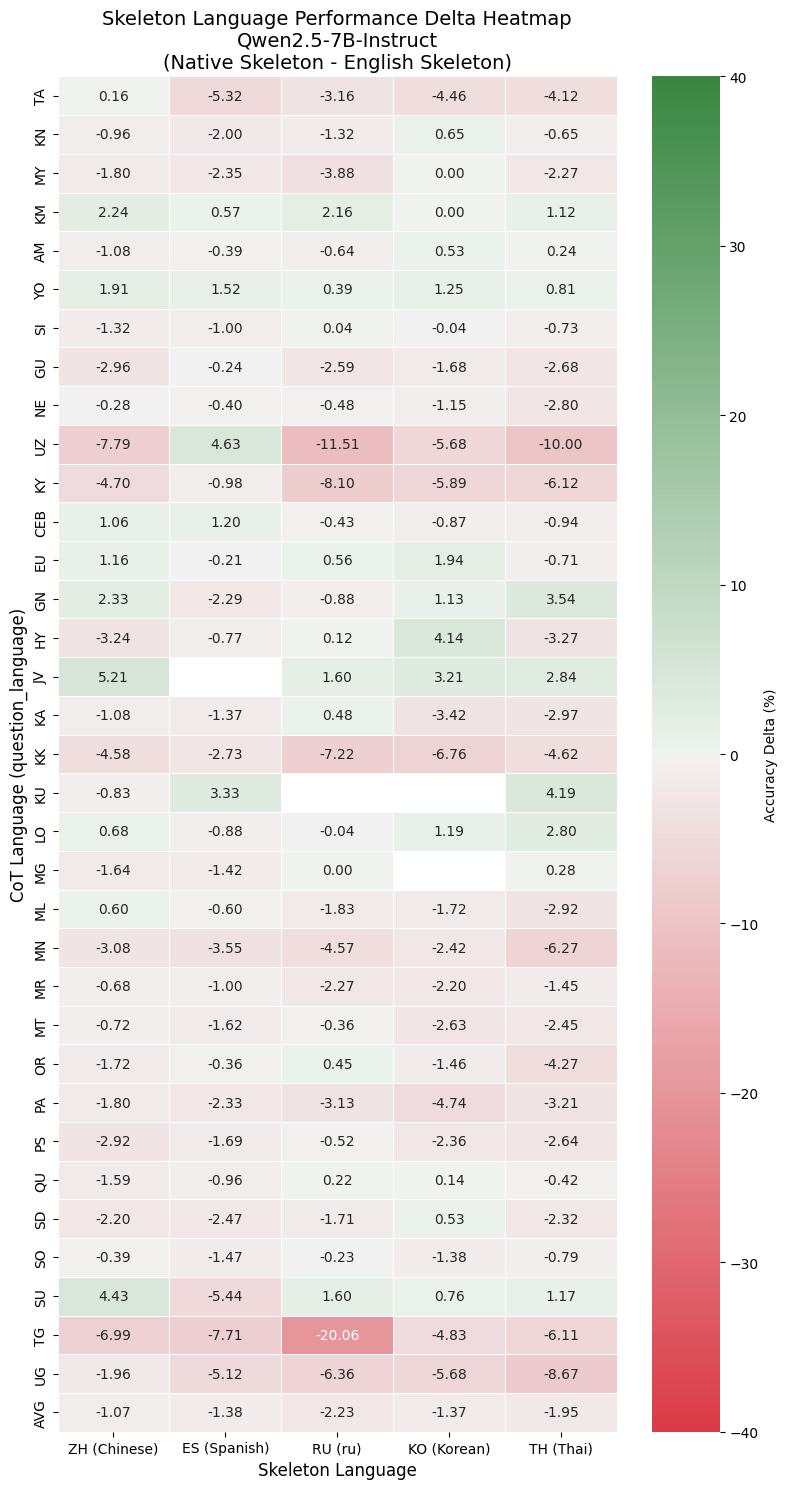

In [7]:
df = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            df.loc[cot_lang, skel_lang] = delta_matrix[skel_lang][cot_lang]
        else:
            df.loc[cot_lang, skel_lang] = np.nan

x_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]

df.loc["AVG"] = df.mean(axis=0, skipna=True)
y_labels = [*y_labels, "AVG"]

plt.figure(figsize=(8, 15))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df.astype(float),
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    vmin=-40,
    vmax=40,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'}
)

plt.title(f"Skeleton Language Performance Delta Heatmap\n{MODEL}\n(Native Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (question_language)", fontsize=12)

if TRANSLATED:
    SAVE_PATH = f"{PRJ_PATH}/figure/TransQ_skeleton_lang_delta_heatmap_{MODEL}.pdf"
else:
    SAVE_PATH = f"{PRJ_PATH}/figure/skeleton_lang_delta_heatmap_{MODEL}.pdf"
plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=500, bbox_inches='tight')
print("✅ Heatmap saved to: skeleton_lang_delta_heatmap.png")
plt.show()


✅ Combined Heatmap saved to: /home/work/mlp/hslim/LASEF2/figure/skeleton_lang_delta_count_heatmap_Qwen2.5-7B-Instruct.pdf


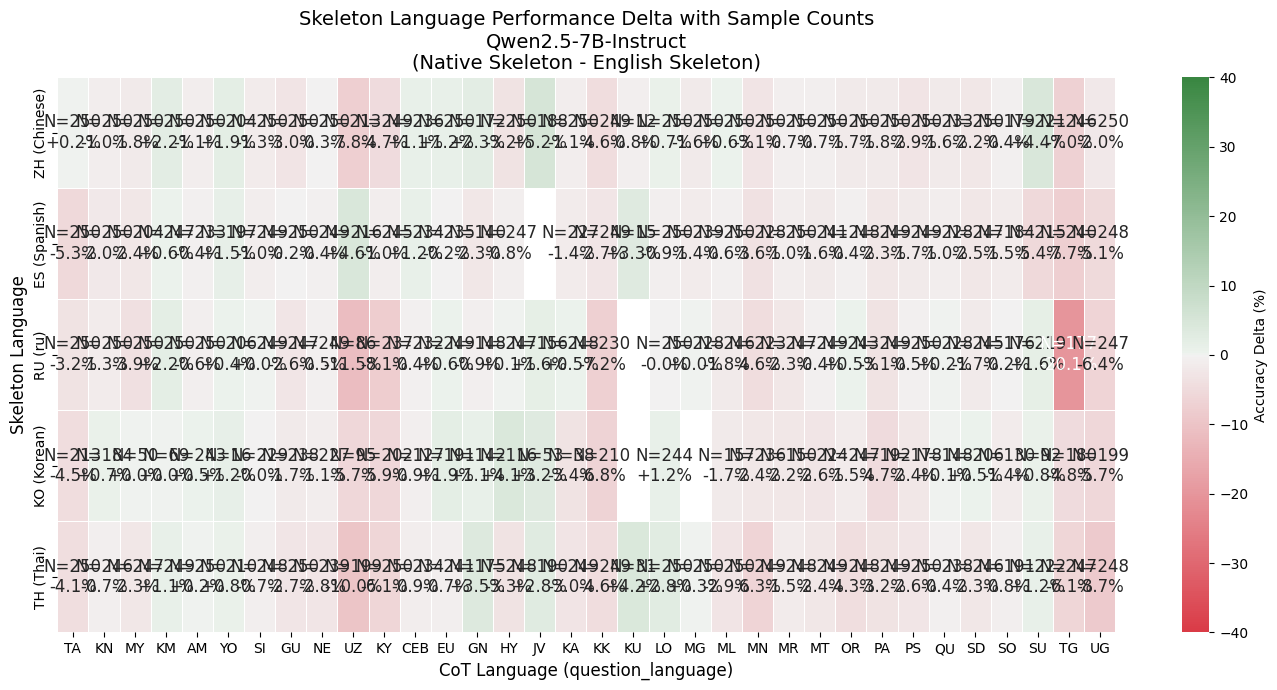

In [8]:
df_delta = pd.DataFrame(index=SKELETON_LANGUAGES, columns=COT_LANGUAGES, dtype=float)
df_count = pd.DataFrame(index=SKELETON_LANGUAGES, columns=COT_LANGUAGES, dtype=float)

for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            df_delta.loc[skel_lang, cot_lang] = delta_matrix[skel_lang][cot_lang]
            df_count.loc[skel_lang, cot_lang] = sample_counts[skel_lang][cot_lang]
        else:
            df_delta.loc[skel_lang, cot_lang] = np.nan
            df_count.loc[skel_lang, cot_lang] = np.nan

annot_combined = np.empty((len(SKELETON_LANGUAGES), len(COT_LANGUAGES)), dtype=object)
for i, skel_lang in enumerate(SKELETON_LANGUAGES):
    for j, cot_lang in enumerate(COT_LANGUAGES):
        delta_val = df_delta.loc[skel_lang, cot_lang]
        count_val = df_count.loc[skel_lang, cot_lang]
        if pd.notna(delta_val) and pd.notna(count_val):
            annot_combined[i, j] = f"N={int(count_val)}\n{delta_val:+.1f}%"
        else:
            annot_combined[i, j] = "N/A"

y_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" for lang in SKELETON_LANGUAGES]
x_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]
plt.figure(figsize=(14, 7))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df_delta.astype(float),
    annot=annot_combined,
    fmt="",
    cmap=cmap,
    center=0,
    vmin=-40,
    vmax=40,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'},
    annot_kws={'fontsize': 12}
)

plt.title(f"Skeleton Language Performance Delta with Sample Counts\n{MODEL}\n(Native Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("CoT Language (question_language)", fontsize=12)
plt.ylabel("Skeleton Language", fontsize=12)

if TRANSLATED:
    SAVE_PATH2 = f"{PRJ_PATH}/figure/TransQ_skeleton_lang_delta_count_heatmap_{MODEL}.pdf"
else:
    SAVE_PATH2 = f"{PRJ_PATH}/figure/skeleton_lang_delta_count_heatmap_{MODEL}.pdf"
plt.tight_layout()
plt.savefig(SAVE_PATH2, dpi=500, bbox_inches='tight')
print(f"✅ Combined Heatmap saved to: {SAVE_PATH2}")
plt.show()

✅ Combined Heatmap (Vertical) saved to: /home/work/mlp/hslim/LASEF2/figure/skeleton_lang_delta_count_heatmap_Qwen2.5-7B-Instruct.pdf


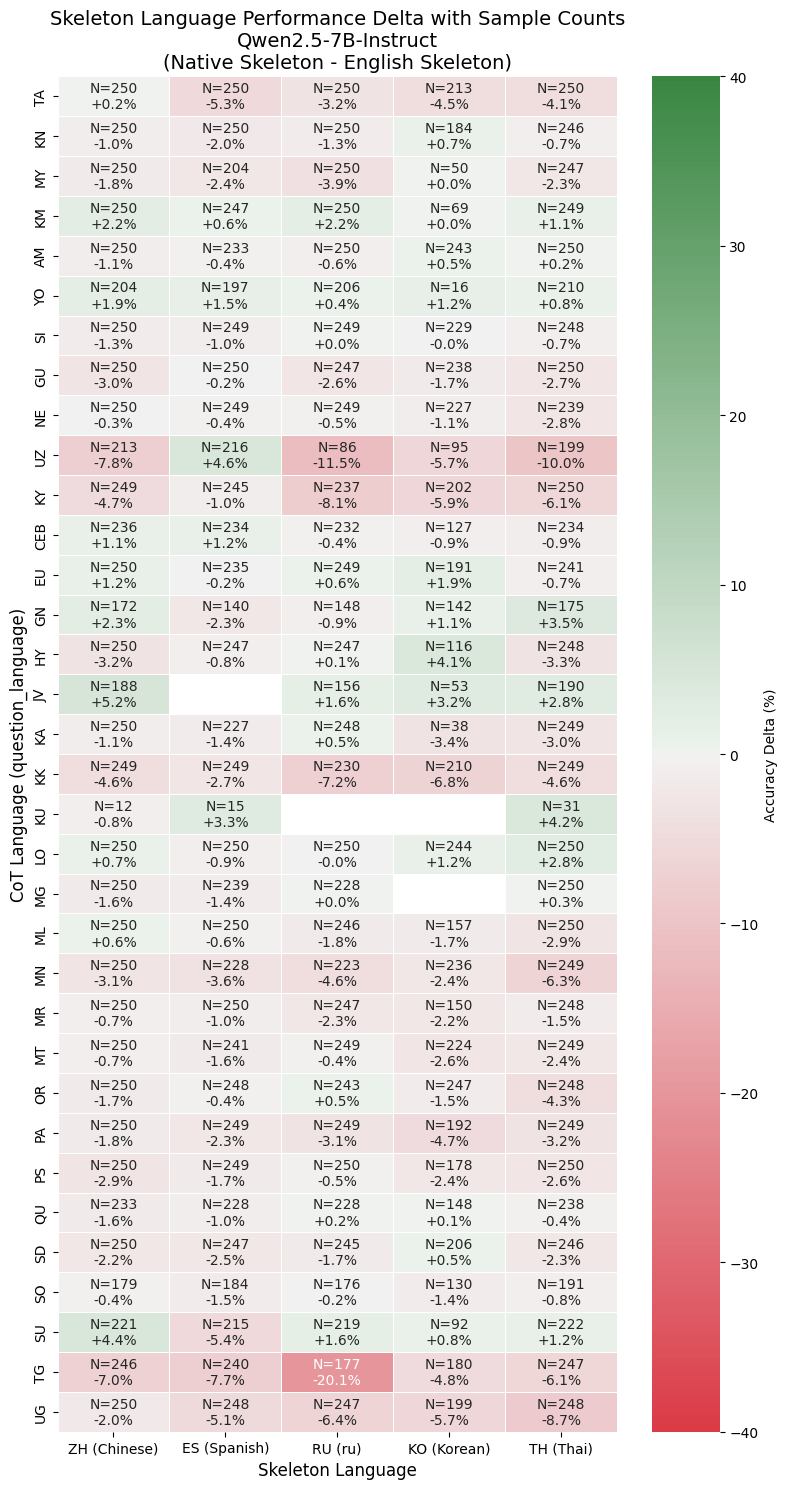

In [9]:
df_delta = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
df_count = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)

for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            df_delta.loc[cot_lang, skel_lang] = delta_matrix[skel_lang][cot_lang]
            df_count.loc[cot_lang, skel_lang] = sample_counts[skel_lang][cot_lang]
        else:
            df_delta.loc[cot_lang, skel_lang] = np.nan
            df_count.loc[cot_lang, skel_lang] = np.nan

annot_combined = np.empty((len(COT_LANGUAGES), len(SKELETON_LANGUAGES)), dtype=object)
for i, cot_lang in enumerate(COT_LANGUAGES):
    for j, skel_lang in enumerate(SKELETON_LANGUAGES):
        delta_val = df_delta.loc[cot_lang, skel_lang]
        count_val = df_count.loc[cot_lang, skel_lang]
        if pd.notna(delta_val) and pd.notna(count_val):
            annot_combined[i, j] = f"N={int(count_val)}\n{delta_val:+.1f}%"
        else:
            annot_combined[i, j] = "N/A"

x_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]


plt.figure(figsize=(8, 15))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df_delta.astype(float),
    annot=annot_combined,
    fmt="",
    cmap=cmap,
    center=0,
    vmin=-40,
    vmax=40,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'},
    annot_kws={'fontsize': 10} 
)

plt.title(f"Skeleton Language Performance Delta with Sample Counts\n{MODEL}\n(Native Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (question_language)", fontsize=12)

if TRANSLATED:
    SAVE_PATH2 = f"{PRJ_PATH}/figure/TransQ_skeleton_lang_delta_count_heatmap_{MODEL}.pdf"
else:
    SAVE_PATH2 = f"{PRJ_PATH}/figure/skeleton_lang_delta_count_heatmap_{MODEL}.pdf"
plt.tight_layout()
plt.savefig(SAVE_PATH2, dpi=500, bbox_inches='tight')
print(f"✅ Combined Heatmap (Vertical) saved to: {SAVE_PATH2}")
plt.show()

In [10]:
SAVE_DIR = f"{PRJ_PATH}/dataframe"

if TRANSLATED:
    delta_path = f"{SAVE_DIR}/TransQ_df_delta_{MODEL}.csv"
    count_path = f"{SAVE_DIR}/TransQ_df_count_{MODEL}.csv"
else:
    delta_path = f"{SAVE_DIR}/df_delta_{MODEL}.csv"
    count_path = f"{SAVE_DIR}/df_count_{MODEL}.csv"

df_delta.to_csv(delta_path, index=True)
df_count.to_csv(count_path, index=True)

print("✔ df_delta / df_count CSV 저장 완료")


✔ df_delta / df_count CSV 저장 완료


## load csv

Original Count: 34, Filtered Count: 34
Excluded: []
✅ Heatmap saved to: /home/work/mlp/hslim/LASEF2/figure/skeleton_lang_delta_heatmap_Qwen2.5-7B-Instruct.pdf


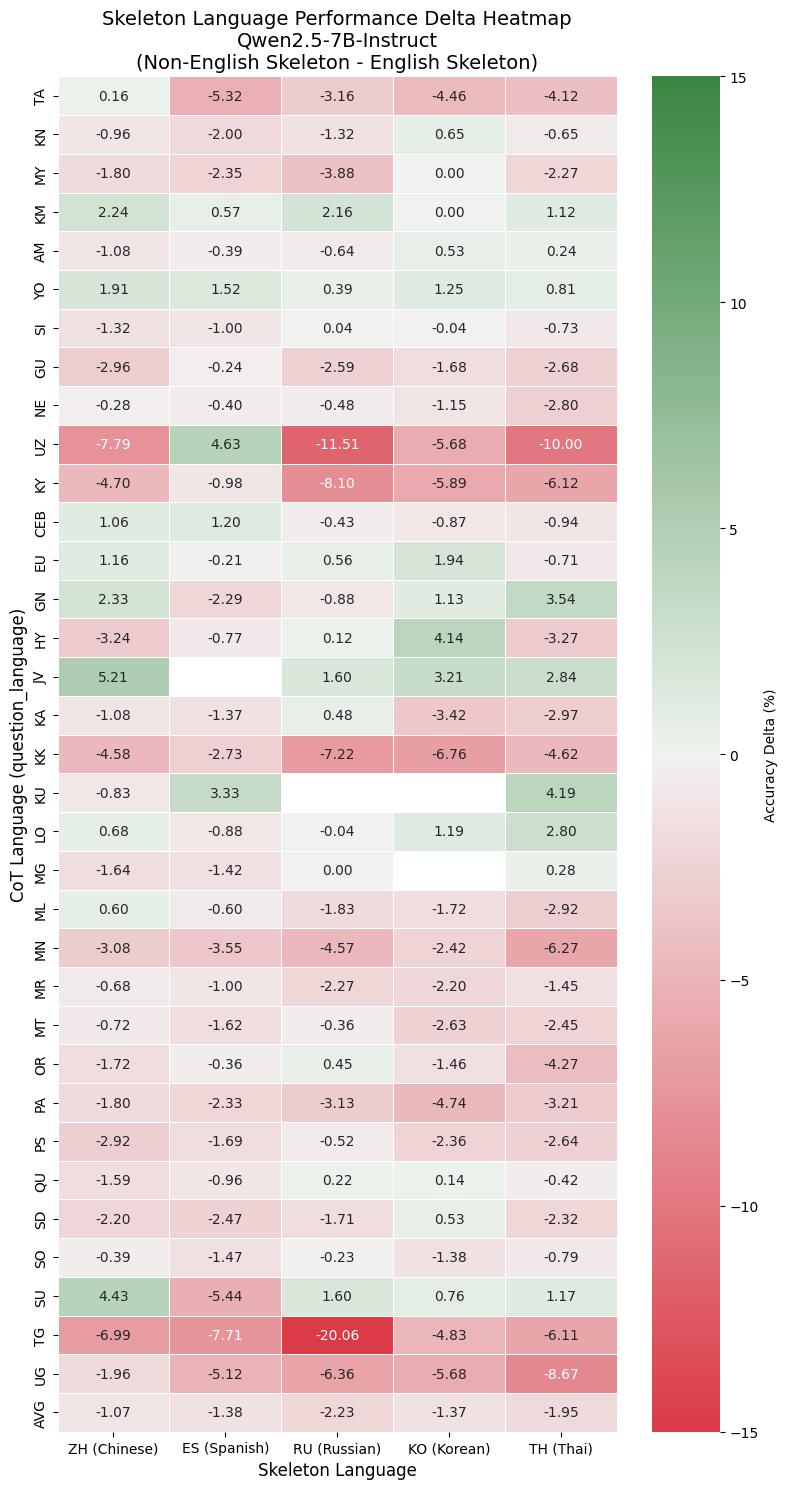

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

TRANSLATED = False
EXCLUDE_LANGS = ["kn",'ku', 'jv', 'mg', 'so', 'gn', 'uz', 'su', 'yo', 'qu', 'ceb', 'ka', 'tg', 'my', 'km']
EXCLUDE_LANGS = []

LANGUAGE_NAMES = {
        "ta": "Tamil", "kn": "Kannada", "my": "Burmese",
        "km": "Khmer", "am": "Amharic", "yo": "Yoruba",
        "si": "Sinhala", "gu": "Gujarati", "ne": "Nepali",
        "uz": "Uzbek", "ky": "Kyrgyz",
        "ceb": "Cebuano", "eu": "Basque", "gn": "Guarani",
        "hy": "Armenian", "jv": "Javanese", "ka": "Georgian",
        "kk": "Kazakh", "ku": "Kurdish", "lo": "Lao",
        "mg": "Malagasy", "ml": "Malayalam", "mn": "Mongolian",
        "mr": "Marathi", "mt": "Maltese", "or": "Odia",
        "pa": "Punjabi", "ps": "Pashto", "qu": "Quechua",
        "sd": "Sindhi", "so": "Somali", "su": "Sundanese",
        "tg": "Tajik", "ug": "Uyghur",
        "en": "English", "zh": "Chinese", "es": "Spanish", "ru": "Russian",
        "ko": "Korean", "th": "Thai", "sw": "Swahili", "te": "Telugu",
    }
SKELETON_LANGUAGES = ["zh", "es", "ru", "ko", "th"]


if TRANSLATED:
    data_path = f"{PRJ_PATH}/dataframe/TransQ_df_delta_{MODEL}.csv"
else:
    data_path = f"{PRJ_PATH}/dataframe/df_delta_{MODEL}.csv"
df_raw = pd.read_csv(data_path, index_col=0)

delta_matrix = df_raw.drop(index=EXCLUDE_LANGS, errors='ignore')

COT_LANGUAGES = delta_matrix.index.tolist()

SKELETON_LANGUAGES = [lang for lang in SKELETON_LANGUAGES if lang not in EXCLUDE_LANGS]

print(f"Original Count: {len(df_raw)}, Filtered Count: {len(delta_matrix)}")
print(f"Excluded: {EXCLUDE_LANGS}")


df = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)

for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            df.loc[cot_lang, skel_lang] = delta_matrix[skel_lang][cot_lang]
        else:
            df.loc[cot_lang, skel_lang] = np.nan

x_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]

df.loc["AVG"] = df.mean(axis=0, skipna=True)
y_labels = [*y_labels, "AVG"]

plt.figure(figsize=(8, 15))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df.astype(float),
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    vmin=-15,
    vmax=15,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'}
)

plt.title(f"Skeleton Language Performance Delta Heatmap\n{MODEL}\n(Non-English Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (question_language)", fontsize=12)

if TRANSLATED:
    SAVE_PATH = f"{PRJ_PATH}/figure/TransQ_skeleton_lang_delta_heatmap_{MODEL}.pdf"
else:
    SAVE_PATH = f"{PRJ_PATH}/figure/skeleton_lang_delta_heatmap_{MODEL}.pdf"

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=500, bbox_inches='tight')
print(f"✅ Heatmap saved to: {SAVE_PATH}")
plt.show()

Original Shape: (34, 5)
Filtered Shape: (19, 5)
Excluded: ['kn', 'ku', 'jv', 'mg', 'so', 'gn', 'uz', 'su', 'yo', 'qu', 'ceb', 'ka', 'tg', 'my', 'km']
✅ Combined Heatmap (Vertical) saved to: /home/work/mlp/hslim/LASEF2/figure/skeleton_lang_delta_count_heatmap_Qwen2.5-7B-Instruct.pdf


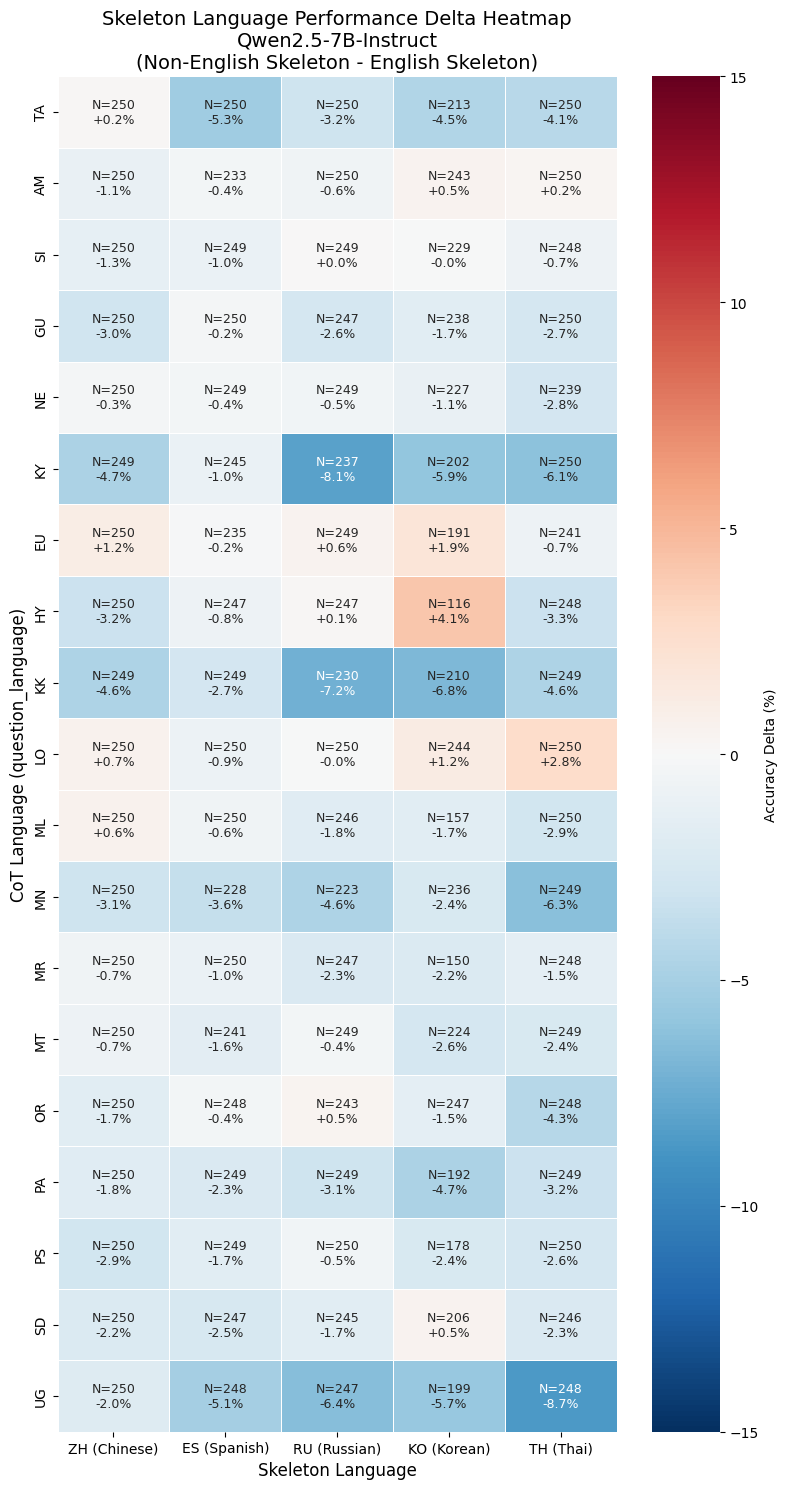

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

TRANSLATED = False
MODEL = "Qwen2.5-7B-Instruct"

if TRANSLATED:
    delta_file_path = f"{PRJ_PATH}/dataframe/TransQ_df_delta_{MODEL}.csv" 
    count_file_path = f"{PRJ_PATH}/dataframe/TransQ_df_count_{MODEL}.csv"
else:
    delta_file_path = f"{PRJ_PATH}/dataframe/df_delta_{MODEL}.csv" 
    count_file_path = f"{PRJ_PATH}/dataframe/df_count_{MODEL}.csv"
df_delta = pd.read_csv(delta_file_path, index_col=0)
df_count = pd.read_csv(count_file_path, index_col=0)

EXCLUDE_LANGS = ["kn",'ku', 'jv', 'mg', 'so', 'gn', 'uz', 'su', 'yo', 'qu', 'ceb', 'ka', 'tg', 'my', 'km']


print(f"Original Shape: {df_delta.shape}")

df_delta = df_delta.drop(index=EXCLUDE_LANGS, errors='ignore')
df_count = df_count.drop(index=EXCLUDE_LANGS, errors='ignore')

COT_LANGUAGES = df_delta.index.tolist()
SKELETON_LANGUAGES = df_delta.columns.tolist()

print(f"Filtered Shape: {df_delta.shape}")
print(f"Excluded: {EXCLUDE_LANGS}")

annot_combined = np.empty((len(COT_LANGUAGES), len(SKELETON_LANGUAGES)), dtype=object)

for i, cot_lang in enumerate(COT_LANGUAGES):
    for j, skel_lang in enumerate(SKELETON_LANGUAGES):
        delta_val = df_delta.loc[cot_lang, skel_lang]
        count_val = df_count.loc[cot_lang, skel_lang]
        
        if pd.notna(delta_val) and pd.notna(count_val):
            annot_combined[i, j] = f"N={int(count_val)}\n{delta_val:+.1f}%"
        else:
            annot_combined[i, j] = "N/A"

x_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" if 'LANGUAGE_NAMES' in globals() else lang.upper() for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]

plt.figure(figsize=(8, 15))
cmap = plt.get_cmap("RdBu_r")


ax = sns.heatmap(
    df_delta.astype(float),
    annot=annot_combined,
    fmt="",   
    cmap=cmap,
    center=0,
    vmin=-15,
    vmax=15,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'},
    annot_kws={'fontsize': 9}
)

plt.title(f"Skeleton Language Performance Delta Heatmap\n{MODEL}\n(Non-English Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (question_language)", fontsize=12)

# 저장 경로 설정
if 'TRANSLATED' in globals() and TRANSLATED:
    SAVE_PATH2 = f"{PRJ_PATH}/figure/TransQ_skeleton_lang_delta_count_heatmap_{MODEL}.pdf"
else:
    SAVE_PATH2 = f"{PRJ_PATH}/figure/skeleton_lang_delta_count_heatmap_{MODEL}.pdf"

plt.tight_layout()
plt.savefig(SAVE_PATH2, dpi=500, bbox_inches='tight')
print(f"✅ Combined Heatmap (Vertical) saved to: {SAVE_PATH2}")
plt.show()

Sorted COT Languages: ['kk', 'ky', 'mn', 'ug', 'hy', 'lo', 'eu', 'mt', 'am', 'ne', 'si', 'ps', 'sd', 'pa', 'gu', 'mr', 'or', 'ta', 'ml']
✅ Sorted Heatmap saved to: /home/work/mlp/hslim/LASEF2/figure/skeleton_lang_delta_heatmap_sorted_Qwen2.5-7B-Instruct.pdf


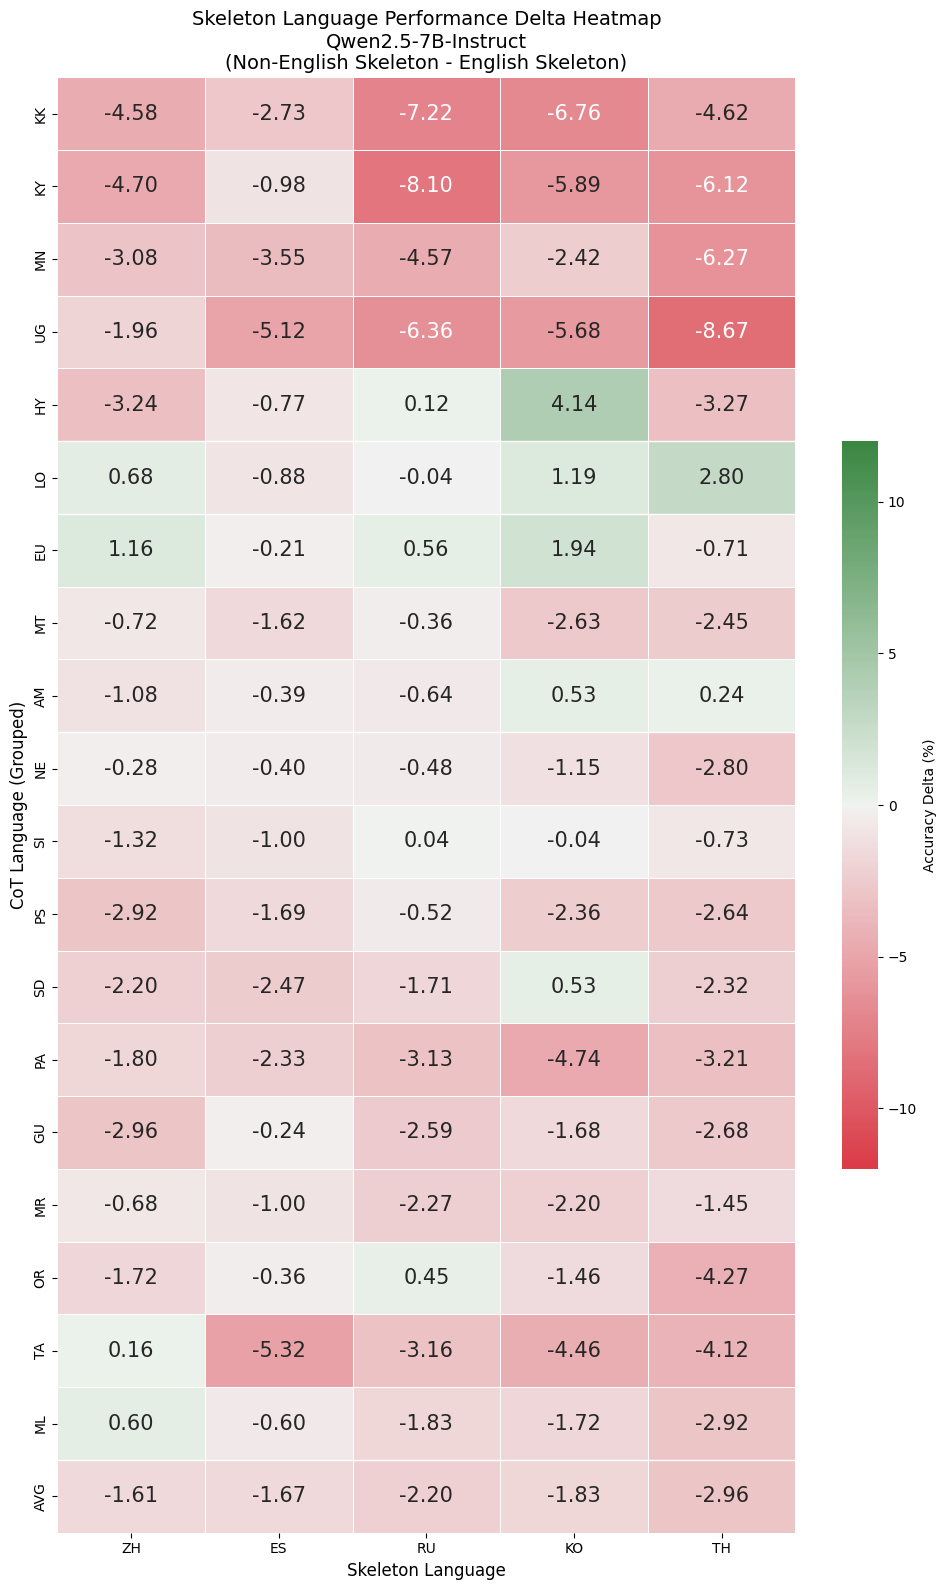

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

TRANSLATED = False

EXCLUDE_LANGS = ["kn",'ku', 'jv', 'mg', 'so', 'gn', 'uz', 'su', 'yo', 'qu', 'ceb', 'ka', 'tg', 'my', 'km']

LANGUAGE_NAMES = {
        "ta": "Tamil", "kn": "Kannada", "my": "Burmese",
        "km": "Khmer", "am": "Amharic", "yo": "Yoruba",
        "si": "Sinhala", "gu": "Gujarati", "ne": "Nepali",
        "uz": "Uzbek", "ky": "Kyrgyz",
        "ceb": "Cebuano", "eu": "Basque", "gn": "Guarani",
        "hy": "Armenian", "jv": "Javanese", "ka": "Georgian",
        "kk": "Kazakh", "ku": "Kurdish", "lo": "Lao",
        "mg": "Malagasy", "ml": "Malayalam", "mn": "Mongolian",
        "mr": "Marathi", "mt": "Maltese", "or": "Odia",
        "pa": "Punjabi", "ps": "Pashto", "qu": "Quechua",
        "sd": "Sindhi", "so": "Somali", "su": "Sundanese",
        "tg": "Tajik", "ug": "Uyghur"
    }


if TRANSLATED:
    data_path = f"{PRJ_PATH}/dataframe/TransQ_df_delta_{MODEL}.csv"
else:
    data_path = f"{PRJ_PATH}/dataframe/df_delta_{MODEL}.csv"
df_raw = pd.read_csv(data_path, index_col=0)

SORT_ORDER_GROUPS = {
    "Cyrillic/Post-Soviet": ['kk', 'ky', 'mn', 'ug', 'hy'], 
    
    "SE Asia (Thai/Pali)": ['lo', 'km', 'my'],
    
    "Euro/Misc": ['eu', 'mt', 'am'],
    
    "Indo-Subcontinent": ['ne', 'si', 'ps', 'sd', 'pa', 'gu', 'mr', 'or', 'ta', 'ml']
}

DESIRED_ORDER = []
for group in SORT_ORDER_GROUPS.values():
    DESIRED_ORDER.extend(group)

delta_matrix = df_raw.drop(index=EXCLUDE_LANGS, errors='ignore')

available_langs = delta_matrix.index.tolist()

sorted_langs = [lang for lang in DESIRED_ORDER if lang in available_langs]

remaining_langs = [lang for lang in available_langs if lang not in sorted_langs]

FINAL_COT_ORDER = sorted_langs + remaining_langs
COT_LANGUAGES = FINAL_COT_ORDER  

print(f"Sorted COT Languages: {COT_LANGUAGES}")

df = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)

for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
             try:
                df.loc[cot_lang, skel_lang] = delta_matrix.loc[cot_lang, skel_lang]
             except:
                df.loc[cot_lang, skel_lang] = delta_matrix[skel_lang][cot_lang]
        else:
            df.loc[cot_lang, skel_lang] = np.nan

x_labels = [f"{lang.upper()}" for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]

df.loc["AVG"] = df.mean(axis=0, skipna=True)
y_labels_final = [*y_labels, "AVG"]

plt.figure(figsize=(10, 16))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df.astype(float),
    annot=True,
    fmt=".2f",
    annot_kws={"size": 15}, 
    cmap=cmap,
    center=0,
    vmin=-12,
    vmax=12,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels_final,
    cbar_kws={'label': 'Accuracy Delta (%)', 'shrink': 0.5} # [수정 4] 컬러바 길이도 80%로 축소
)

current_idx = 0
for group_name, langs in SORT_ORDER_GROUPS.items():
    count = sum(1 for lang in langs if lang in COT_LANGUAGES)
    if count > 0:
        current_idx += count
        ax.hlines(current_idx, *ax.get_xlim(), colors='white', linewidth=1)
        

plt.title(f"Skeleton Language Performance Delta Heatmap\n{MODEL}\n(Non-English Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (Grouped)", fontsize=12)

if TRANSLATED:
    SAVE_PATH = f"{PRJ_PATH}/figure/TransQ_skeleton_lang_delta_heatmap_sorted_{MODEL}.pdf"
else:
    SAVE_PATH = f"{PRJ_PATH}/figure/skeleton_lang_delta_heatmap_sorted_{MODEL}.pdf"

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=500, bbox_inches='tight')
print(f"✅ Sorted Heatmap saved to: {SAVE_PATH}")
plt.show()

In [14]:
df

,zh,es,ru,ko,th
kk,-4.578313,-2.730924,-7.217391,-6.761905,-4.618474
ky,-4.698795,-0.979592,-8.101266,-5.891089,-6.120000
mn,-3.080000,-3.552632,-4.573991,-2.415254,-6.265060
ug,-1.960000,-5.120968,-6.356275,-5.678392,-8.669355
hy,-3.240000,-0.769231,0.121457,4.137931,-3.266129
lo,0.680000,-0.880000,-0.040000,1.188525,2.800000
eu,1.160000,-0.212766,0.562249,1.937173,-0.705394
mt,-0.720000,-1.618257,-0.361446,-2.633929,-2.449799
am,-1.080000,-0.386266,-0.640000,0.534979,0.240000
ne,-0.280000,-0.401606,-0.481928,-1.145374,-2.803347
